Lab - EDA Bivariate Analysis: Diving into Amazon UK Product Insights Part II

Objective: Delve into the dynamics of product pricing on Amazon UK to uncover insights that can inform business strategies and decision-making.

Dataset: This lab utilizes the Amazon UK product dataset which provides information on product categories, brands, prices, ratings, and more from from Amazon UK. You'll need to download it to start working with it.

In [1]:
# Load data set:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Replace with your actual file name
df = pd.read_csv("amz_uk_price_prediction_dataset.csv")

# Quick check: see first 5 rows
df.head(5)


,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


Part 1: Analyzing Best-Seller Trends Across Product Categories

Objective: Understand the relationship between product categories and their best-seller status.

1. Crosstab Analysis:

1.1 Create a crosstab between the product category and the isBestSeller status.

1.2 Are there categories where being a best-seller is more prevalent?

Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.

2. Statistical Tests:

2.1 Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
2.2 Compute Cramér's V to understand the strength of association between best-seller status and category.

3.Visualizations:

3.1 Visualize the relationship between product categories and the best-seller status using a stacked bar chart.


In [2]:
# 1.1 Create a crosstab between the product category and the isBestSeller status.

pd.crosstab(df["category"], df["isBestSeller"])

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


In [3]:
# save crosstab
crosstab = pd.crosstab(df["category"], df["isBestSeller"])
crosstab.head()

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3


In [5]:
# adding totals
pd.crosstab(
    df["category"],
    df["isBestSeller"],
    margins=True
)

isBestSeller,False,True,All
category,,,
3D Printers,247,1,248
3D Printing & Scanning,4065,2,4067
Abrasive & Finishing Products,245,5,250
Action Cameras,1696,1,1697
Adapters,251,3,254
...,...,...,...
Window Treatments,234,5,239
Women,17559,213,17772
Women's Sports & Outdoor Shoes,1939,20,1959


In [6]:
# Percentages
crosstab_pct = pd.crosstab(
df["category"],
df["isBestSeller"],
normalize="index"
) * 100
crosstab_pct.round(2)

isBestSeller,False,True
category,,
3D Printers,99.60,0.40
3D Printing & Scanning,99.95,0.05
Abrasive & Finishing Products,98.00,2.00
Action Cameras,99.94,0.06
Adapters,98.82,1.18
...,...,...
Wind Instruments,97.20,2.80
Window Treatments,97.91,2.09
Women,98.80,1.20


1.2 Are there categories where being a best-seller is more prevalent?
Wind Instruments (2.80%) has the highest Best Seller rate among the categories shown.
Window Treatments (2.09%) and Abrasive & Finishing Products (2.00%) also have relatively high proportions of Best Sellers.

In [8]:
# 2.1 Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.

crosstab = pd.crosstab(df["category"], df["isBestSeller"])
crosstab.head()

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3


In [9]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(crosstab)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 36540.20270061387
p-value: 0.0
Degrees of freedom: 295


In [10]:
import numpy as np

n = crosstab.sum().sum()

cramers_v = np.sqrt(

chi2 / (n * (min(crosstab.shape) - 1))
)

print("Cramér's V:", cramers_v)

Cramér's V: 0.1222829439760564


Best Seller status is not independent of product category.
Although there is a statistically significant relationship between category and Best Seller status, the strength of that relationship is weak as shown by Cramer's value of 0.122 indicates a weak association.

In [11]:
# 3.1 Visualize the relationship between product categories and the best-seller status using a stacked bar chart.
crosstab = pd.crosstab(df["category"], df["isBestSeller"])

In [14]:
top_categories = df["category"].value_counts().head(10).index
crosstab_top = crosstab.loc[top_categories]

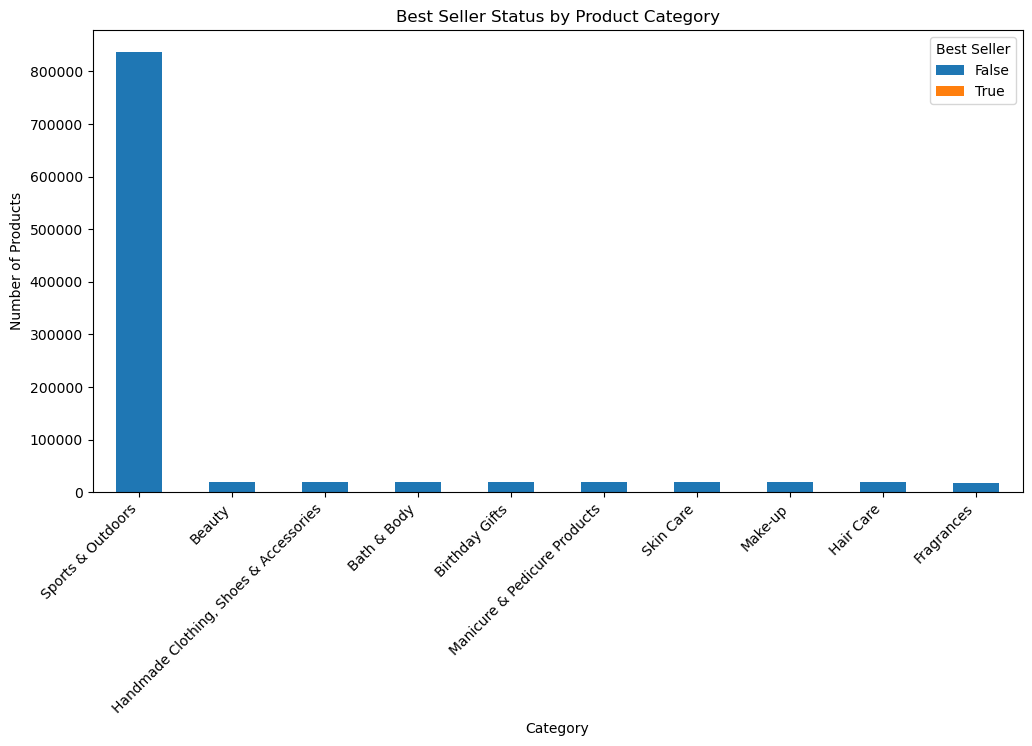

In [15]:
crosstab_top.plot(
kind="bar",
stacked=True,
figsize=(12,6)
)

plt.title("Best Seller Status by Product Category")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.legend(title="Best Seller")
plt.xticks(rotation=45, ha="right")
plt.show()

Part 2: Exploring Product Prices and Ratings Across Categories and Brands
Objective: Investigate how different product categories influence product prices.

0. Preliminary Step: Remove outliers in product prices.

For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.

Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.

1. Violin Plots:

Use a violin plot to visualize the distribution of price across different product categories. Filter out the top 20 categories based on count for better visualization.
Which product category tends to have the highest median price? Don't filter here by top categories.

2. Bar Charts:

Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
Which product category commands the highest average price? Don't filter here by top categories.

3. Box Plots:

Visualize the distribution of product ratings based on their category using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
Which category tends to receive the highest median rating from customers? Don't filter here by top categories.

In [21]:
# Remove outliers

Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -44.01
Upper Bound: 99.99000000000001


In [22]:
df_no_outliers = df[
    (df["price"] >= lower_bound) &
    (df["price"] <= upper_bound)
]

print("Original shape:", df.shape)
print("Without outliers:", df_no_outliers.shape)

Original shape: (2443651, 9)
Without outliers: (2115963, 9)


In [23]:
top20_categories = (
    df_no_outliers["category"]
    .value_counts()
    .head(20)
    .index
)

top20_df = df_no_outliers[
df_no_outliers["category"].isin(top20_categories)
]

In [25]:
top20_df.groupby("category")["price"].median().sort_values(ascending=False)

category
Men                                       20.990
Fragrances                                20.000
Sports & Outdoors                         18.320
Women                                     15.990
Handmade Jewellery                        15.600
Handmade Artwork                          14.990
Birthday Gifts                            13.990
Luggage and travel gear                   13.990
Baby                                      12.990
Handmade Gifts                            12.990
Handmade Kitchen & Dining                 12.000
Skin Care                                 12.000
Handmade Home Décor                       11.990
Bath & Body                               11.635
Handmade Home & Kitchen Products          10.990
Hair Care                                  9.970
Handmade Clothing, Shoes & Accessories     8.990
Beauty                                     8.990
Manicure & Pedicure Products               7.500
Make-up                                    7.000
Name: price

1.1 Violin Plots:

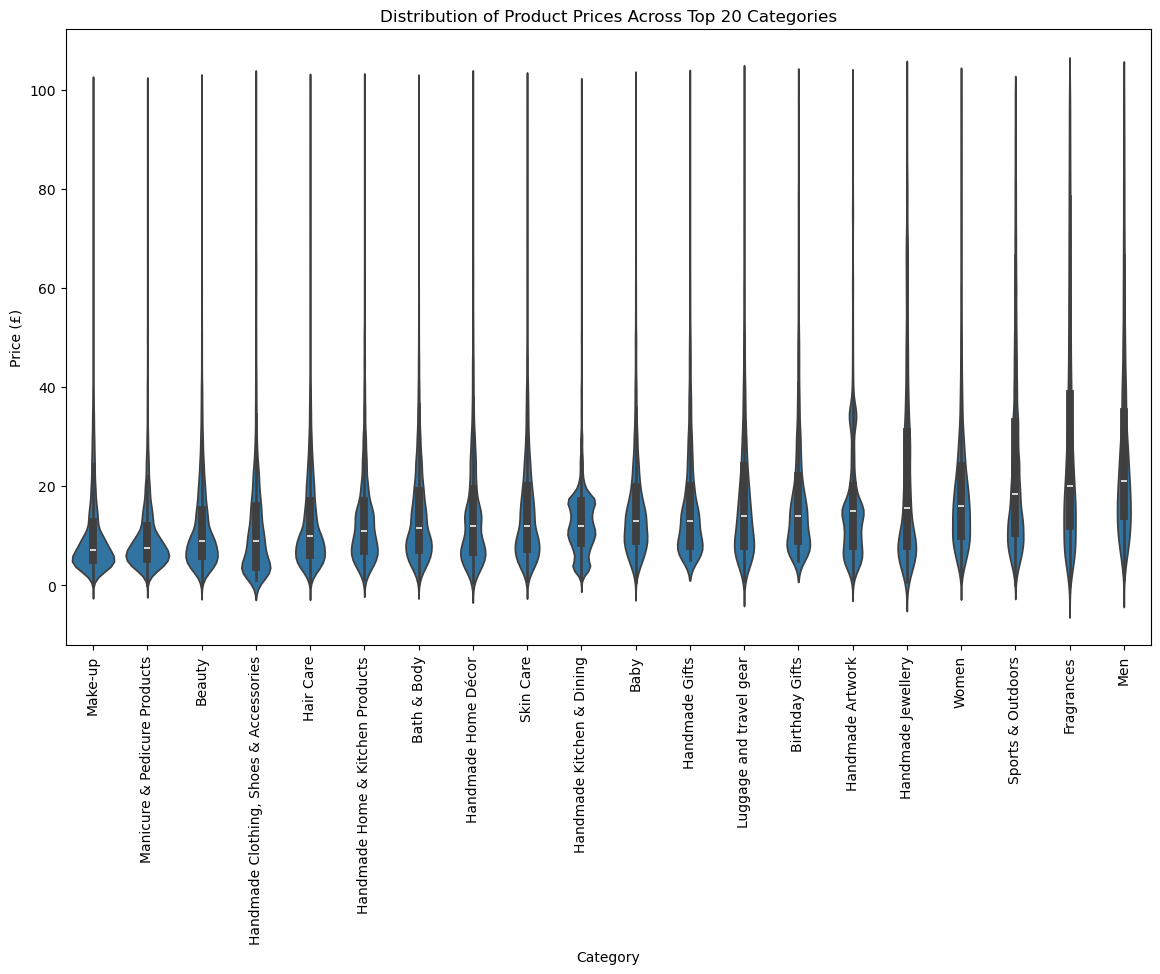

In [24]:
plt.figure(figsize=(14,8))

sns.violinplot(
    data=top20_df,
    x="category",
    y="price",
    order=top20_df.groupby("category")["price"]
                    .median()
                    .sort_values()
                    .index
)

plt.xticks(rotation=90)
plt.title("Distribution of Product Prices Across Top 20 Categories")
plt.xlabel("Category")
plt.ylabel("Price (£)")
plt.show()

1.2 Which product category tends to have the highest median price? Don't filter here by top categories.
Men has its median positioned the highest on the y-axis (around £20–£22).
Fragrances and Sports & Outdoors also have relatively high medians, but slightly lower than Men.
Categories such as Make-up, Manicure & Pedicure Products, and Beauty have noticeably lower medians (around £5–£8).

In [26]:
df_no_outliers.groupby("category")["price"].median() \
                .sort_values(ascending=False) \
                .head(10)

category
Desktop PCs               74.00
Boxing Shoes              69.79
Tablets                   69.00
Graphics Cards            68.54
Motherboards              67.92
Made in Italy Handmade    64.00
Digital Frames            63.90
Streaming Clients         62.68
Golf Shoes                62.39
Ski Helmets               61.33
Name: price, dtype: float64

2. Bar Charts:

Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
Which product category commands the highest average price? Don't filter here by top categories.


In [27]:
# Top 10 product categories

top10_categories = (
    df_no_outliers["category"]
    .value_counts()
    .head(10)
    .index
)

top10_categories

Index(['Sports & Outdoors', 'Beauty', 'Bath & Body',
       'Manicure & Pedicure Products',
       'Handmade Clothing, Shoes & Accessories', 'Make-up', 'Skin Care',
       'Hair Care', 'Birthday Gifts', 'Handmade Gifts'],
      dtype='str', name='category')

In [28]:
# Average Prices 
avg_prices = (
    df_no_outliers[df_no_outliers["category"].isin(top10_categories)]
    .groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
)

avg_prices

category
Sports & Outdoors                         25.172065
Birthday Gifts                            18.600195
Handmade Gifts                            17.395112
Skin Care                                 15.654722
Bath & Body                               14.678683
Hair Care                                 13.461408
Handmade Clothing, Shoes & Accessories    12.958639
Beauty                                    12.523480
Make-up                                   10.612918
Manicure & Pedicure Products              10.231825
Name: price, dtype: float64

/var/folders/t1/g1ptmxln4nx5k_rz9978lf340000gn/T/ipykernel_83700/2926195943.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='category'>

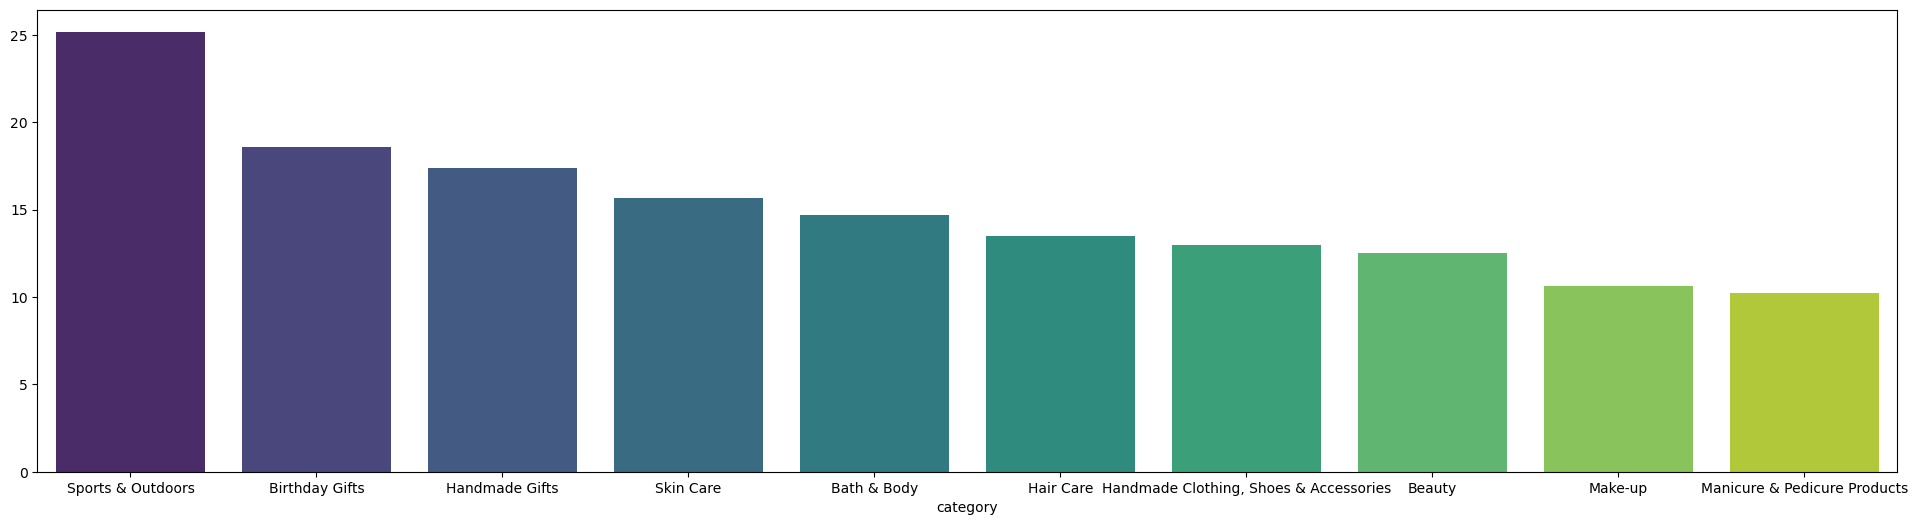

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(24,6))

sns.barplot(
    x=avg_prices.index,
    y=avg_prices.values,
    palette="viridis"
)

/var/folders/t1/g1ptmxln4nx5k_rz9978lf340000gn/T/ipykernel_83700/4292571251.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


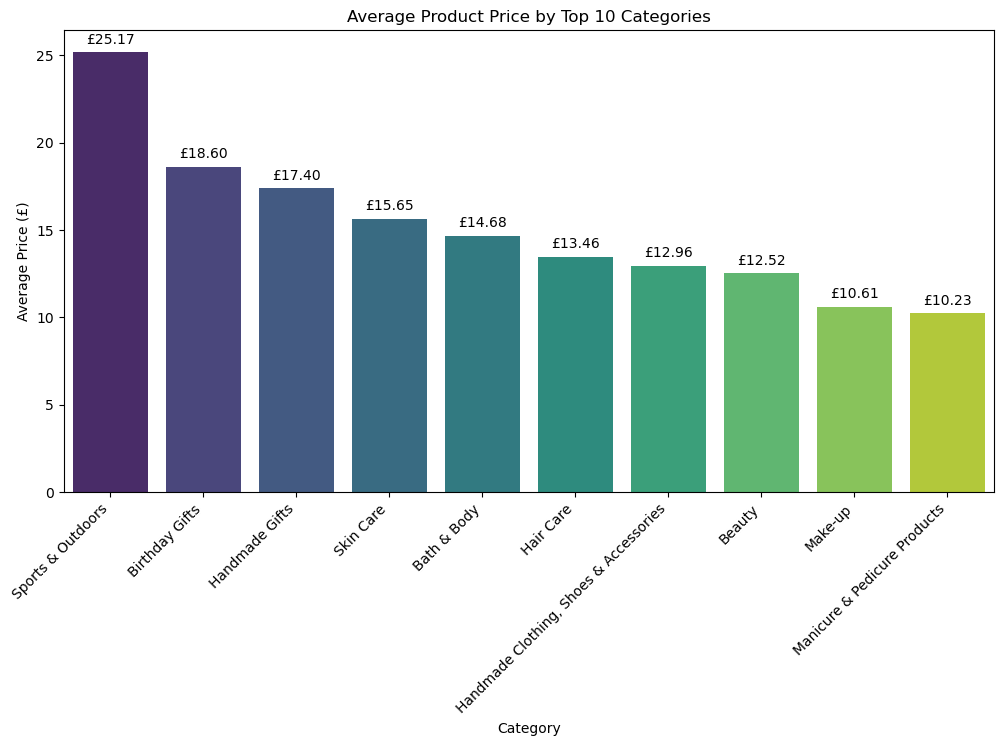

In [31]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=avg_prices.index,
    y=avg_prices.values,
    palette="viridis"
)

for i, value in enumerate(avg_prices.values):
    ax.text(i, value + 0.5, f"£{value:.2f}", ha="center")

plt.title("Average Product Price by Top 10 Categories")
plt.xlabel("Category")
plt.ylabel("Average Price (£)")
plt.xticks(rotation=45, ha="right")
plt.show()

2. Which product category commands the highest average price? Don't filter here by top categories.

Sports & Outdoors commmands the highest average price followed by Birtday Gifts and Handmade Gifts. 

3. Box Plots:

Visualize the distribution of product ratings based on their category using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
Which category tends to receive the highest median rating from customers? Don't filter here by top categories.

In [32]:
# TOP 10 
top10_categories = (
    df["category"]
    .value_counts()
    .head(10)
    .index
)

top10_categories

Index(['Sports & Outdoors', 'Beauty', 'Handmade Clothing, Shoes & Accessories',
       'Bath & Body', 'Birthday Gifts', 'Manicure & Pedicure Products',
       'Skin Care', 'Make-up', 'Hair Care', 'Fragrances'],
      dtype='str', name='category')

In [33]:
# Filter dataset - remove zero rating

top10_df = df[df["category"].isin(top10_categories)]

top10_df = top10_df[top10_df["stars"] > 0]

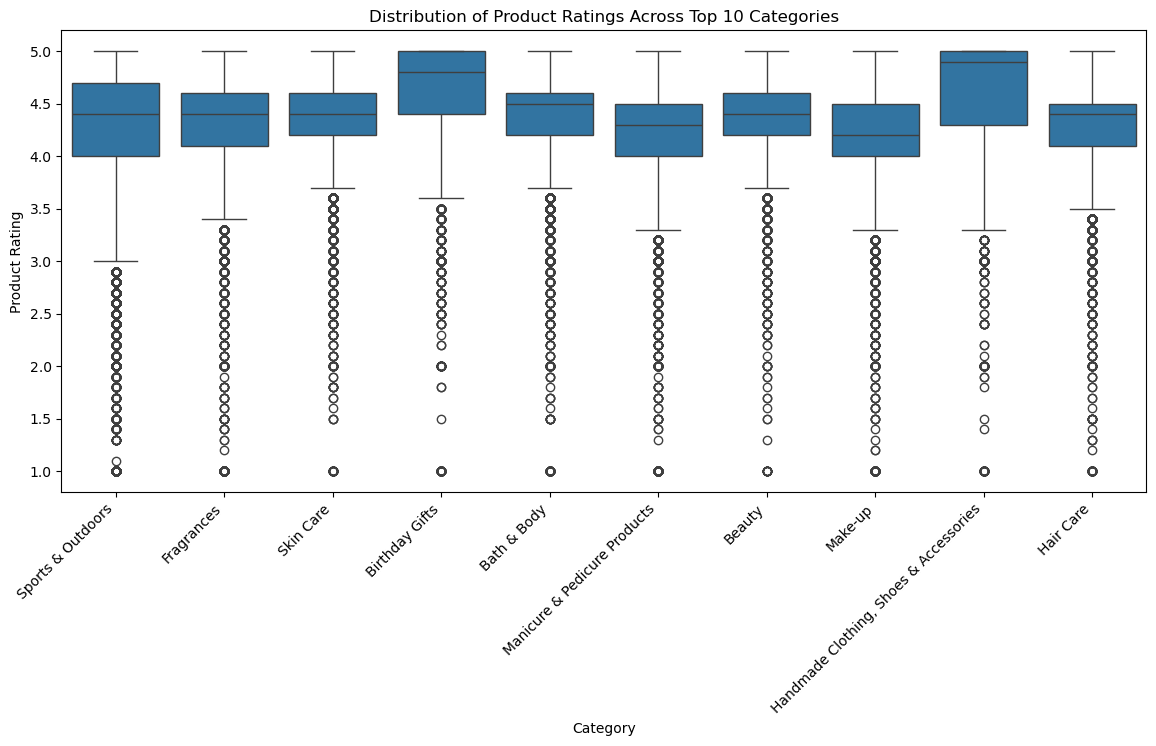

In [35]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=top10_df,
    x="category",
    y="stars"
    
)

plt.title("Distribution of Product Ratings Across Top 10 Categories")
plt.xlabel("Category")
plt.ylabel("Product Rating")
plt.xticks(rotation=45, ha="right")

plt.show()

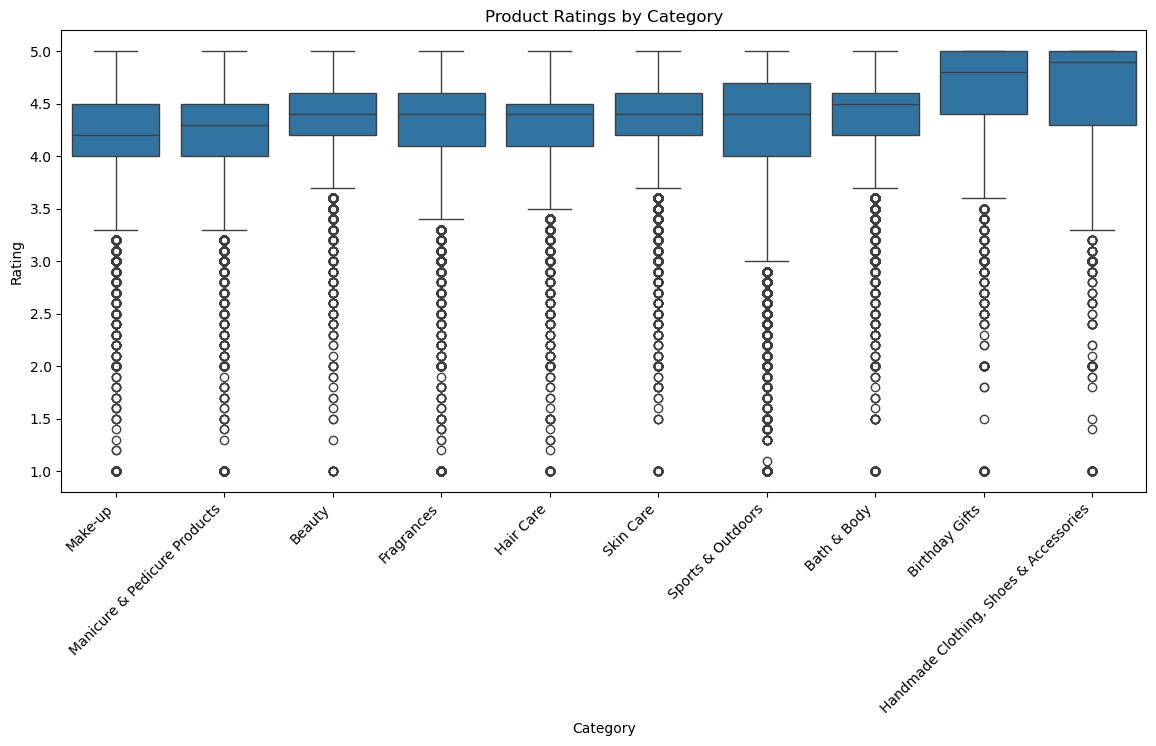

In [37]:
order = (
top10_df.groupby("category")["stars"]
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(14,6))

sns.boxplot(
    data=top10_df,
    x="category",
    y="stars",
    order=order
)

plt.title("Product Ratings by Category")
plt.xlabel("Category")
plt.ylabel("Rating")
plt.xticks(rotation=45, ha="right")

plt.show()

In [38]:
# highest rated categories

top10_df.groupby("category")["stars"] \
    .median() \
    .sort_values(ascending=False)

category
Handmade Clothing, Shoes & Accessories    4.9
Birthday Gifts                            4.8
Bath & Body                               4.5
Beauty                                    4.4
Fragrances                                4.4
Hair Care                                 4.4
Skin Care                                 4.4
Sports & Outdoors                         4.4
Manicure & Pedicure Products              4.3
Make-up                                   4.2
Name: stars, dtype: float64

3. Which category tends to receive the highest median rating from customers?

Handmade Clothing, Shoes & Accessories & Birthday Gifts are the categories with the highest median rating from customer. 

Part 3: Investigating the Interplay Between Product Prices and Ratings
Objective: Analyze how product ratings (stars) correlate with product prices.

1. Correlation Coefficients:

1.1 Calculate the correlation coefficient between price and stars.
1.2 Is there a significant correlation between product price and its rating?

2. Visualizations:

2.1 Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
2.2 Use a correlation heatmap to visualize correlations between all numerical variables.
2.3 Examine if product prices typically follow a normal distribution using a QQ plot.


1.1 Correlation Coefficients: Calculate the correlation coefficient between price and stars.

In [39]:
ratings_df = df_no_outliers[df_no_outliers["stars"] > 0]

In [40]:
correlation = ratings_df["price"].corr(ratings_df["stars"])

print("Correlation coefficient:", correlation)

Correlation coefficient: 0.006744508067158014


In [41]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(
    ratings_df["price"],
    ratings_df["stars"]
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.0067445080671579795
P-value: 1.0813032347765859e-12


1.2 Is there a significant correlation between product price and its rating?
Although the correlation between product price and rating is statistically significant (p < 0.05), the correlation coefficient (r = 0.0067) is extremely close to zero. This indicates that the relationship between price and rating is negligible in practical terms. Therefore, more expensive products do not tend to receive higher or lower ratings than cheaper products. Product price appears to have little influence on customer ratings.

2. Visualizations: 

2.1 Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?

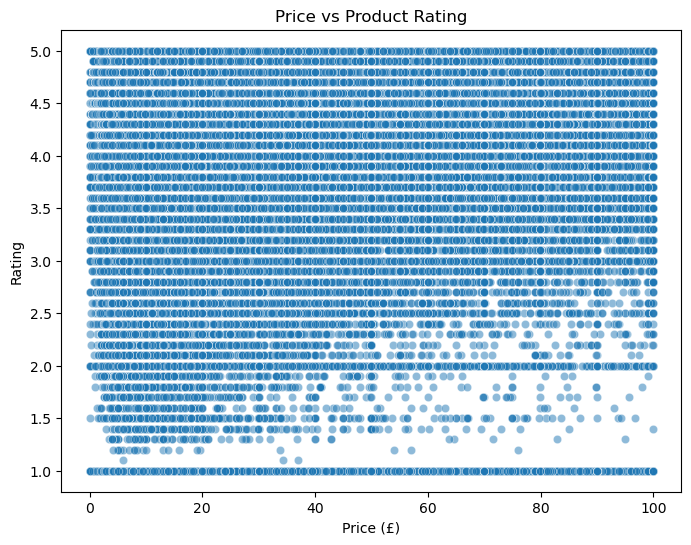

In [42]:
plt.figure(figsize=(8,6))

sns.scatterplot(
data=ratings_df,
x="price",
y="stars",
alpha=0.5
)
Use a correlation heatmap to visualize correlations between all numerical variables.
plt.title("Price vs Product Rating")
plt.xlabel("Price (£)")
plt.ylabel("Rating")

plt.show()

2.1 What patterns can you observe? 
Ratings are spread across almost all price levels (£0–£100).
Most products have ratings between 3.5 and 5.0, regardless of price.
There is no visible upward or downward trend.
Products with both high and low ratings exist at nearly every price point.
Price and rating show a negligible positive correlation (r = 0.0067). The scatter plot reveals no clear trend, suggesting that product price has little to no practical impact on customer ratings.

2.2 Use a correlation heatmap to visualize correlations between all numerical variables.

In [43]:
# Select Numerical Columns

df_no_outliers.select_dtypes(include="number").columns

Index(['uid', 'stars', 'reviews', 'price', 'boughtInLastMonth'], dtype='str')

In [44]:
# Create Correlation Matrix

corr_matrix = df_no_outliers.select_dtypes(include="number").corr()

corr_matrix

,uid,stars,reviews,price,boughtInLastMonth
uid,1.000000,0.030288,0.020236,0.001717,0.017116
stars,0.030288,1.000000,0.083920,-0.077673,0.113994
reviews,0.020236,0.083920,1.000000,-0.008498,0.105624
price,0.001717,-0.077673,-0.008498,1.000000,-0.059051
boughtInLastMonth,0.017116,0.113994,0.105624,-0.059051,1.000000


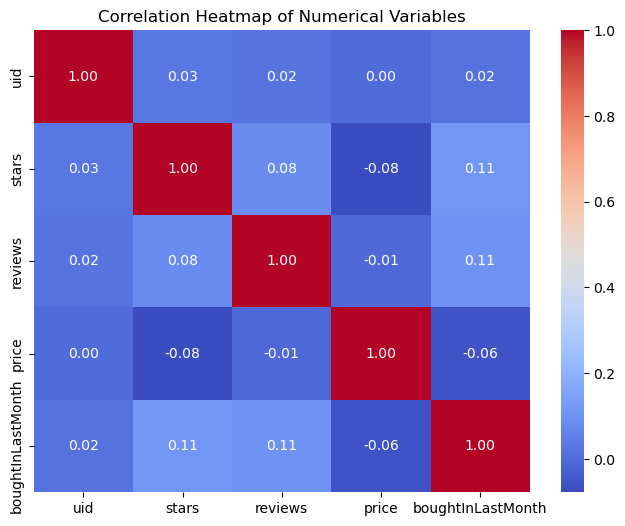

In [52]:
# Plot Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"

)

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

The correlation heatmap shows weak correlations among most numerical variables. In particular, the correlation between price and rating (stars) is close to zero, suggesting that product price has little impact on customer ratings.

2.3 Examine if product prices typically follow a normal distribution using a QQ plot.

In [54]:
import scipy.stats as stats

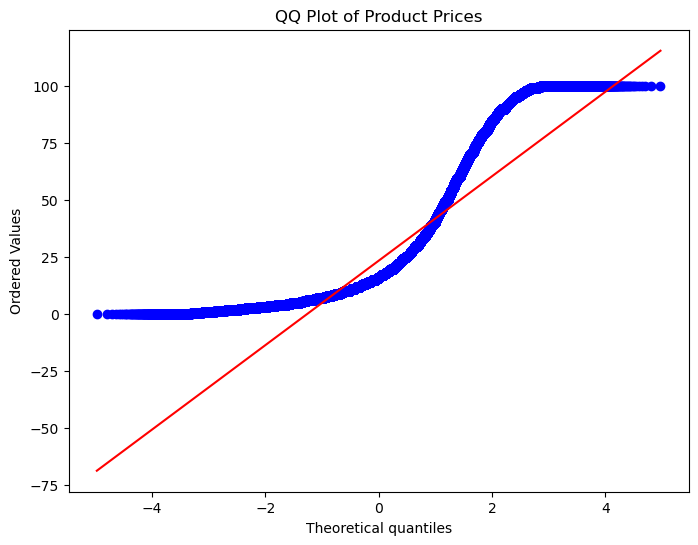

In [55]:
plt.figure(figsize=(8,6))

stats.probplot(
df_no_outliers["price"],
dist="norm",
plot=plt
)

plt.title("QQ Plot of Product Prices")

plt.show()

In [56]:
df_no_outliers["price"].skew()

np.float64(1.6383204687806214)

Bonus:

3. Do the same analysis without taking out the outliers. What are your insights?

In [57]:
corr_matrix = df.select_dtypes(include="number").corr()

corr_matrix

,uid,stars,reviews,price,boughtInLastMonth
uid,1.000000,0.031696,0.019994,0.008273,0.016336
stars,0.031696,1.000000,0.085808,-0.124907,0.112536
reviews,0.019994,0.085808,1.000000,-0.013171,0.104043
price,0.008273,-0.124907,-0.013171,1.000000,-0.023439
boughtInLastMonth,0.016336,0.112536,0.104043,-0.023439,1.000000


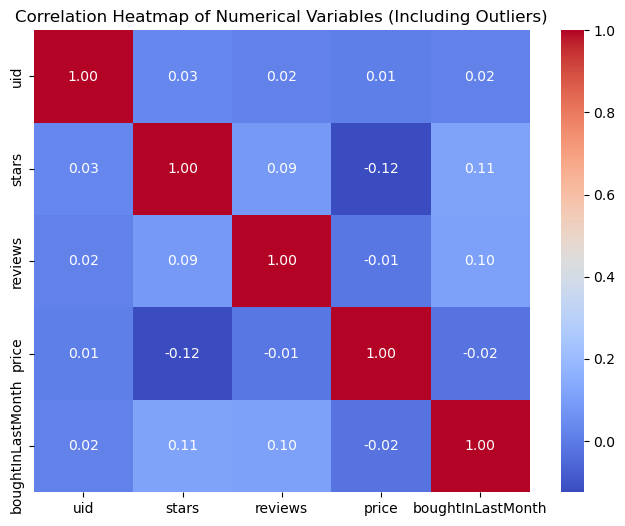

In [58]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"

)

plt.title("Correlation Heatmap of Numerical Variables (Including Outliers)")
plt.show()

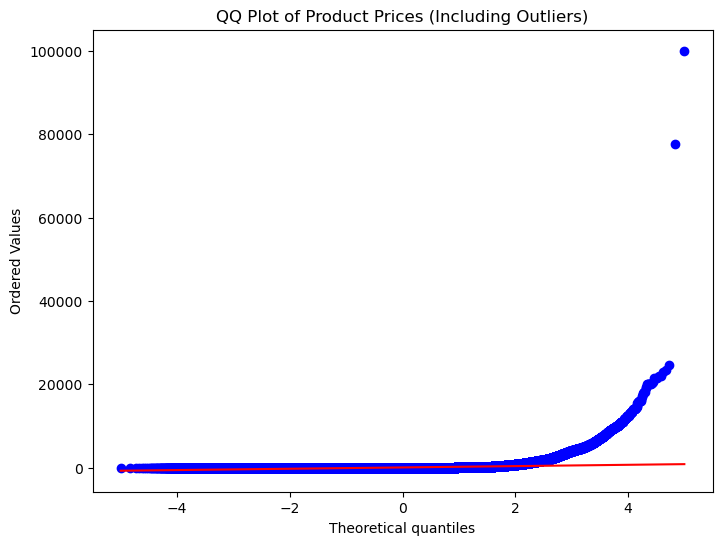

In [60]:
import scipy.stats as stats

plt.figure(figsize=(8,6))

stats.probplot(
    df["price"],
    dist="norm",
    plot=plt
)

plt.title("QQ Plot of Product Prices (Including Outliers)")
plt.show()

What are your insights?
After removing outliers, product prices remain right-skewed (skewness = 1.64). Correlation analysis reveals that price has a weak negative relationship with ratings (-0.125), suggesting more expensive products are not necessarily rated more highly. Ratings and review counts show small positive associations with recent purchases, indicating that customer feedback may play a modest role in driving sales. Overall, the dataset exhibits only weak linear relationships between variables, implying that multiple factors likely influence customer behavior.